In [9]:
from PIL import Image

In [37]:
img = Image.open('IMG_8052.jpg')

In [49]:
import torch
import torchvision.models as models
from torchvision import transforms
import numpy as np
import cv2
class VisionModel():
    def __init__(self):
        self.model = models.resnet50(pretrained=True)
        self.model.fc = torch.nn.Linear(self.model.fc.in_features, 14*2)
        self.model.load_state_dict(torch.load('model_weights/best_model_noresize.pth', map_location=torch.device("cpu")))
    def predict(self, image):
        self.model.eval()
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()])
        original_size = image.size
        image = transform(image)
        with torch.no_grad():
            image = image.unsqueeze(0) 
            output = self.model(image).cpu().detach().numpy().reshape(-1, 2)
            output[:, 0] *= original_size[0] / 224
            output[:, 1] *= original_size[1] / 224
        return output
    def crop_based_angle(self, image):
        self.model.eval()
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()])
        original_size = image.size
        h, w = original_size[1], original_size[0]
        image_transformed = transform(image)
        with torch.no_grad():
            image_transformed = image_transformed.unsqueeze(0) 
            output = self.model(image_transformed).cpu().detach().numpy().reshape(-1, 2)
            output[:, 0] *= original_size[0] / 224
            output[:, 1] *= original_size[1] / 224
        (x1, y1), (x2, y2) = output[5], output[7]
        dx = x2 - x1
        dy = y2 - y1
        angle_rad = np.arctan2(dy, dx)
        angle_deg = np.degrees(angle_rad)

        cos = np.abs(np.cos(angle_rad))
        sin = np.abs(np.sin(angle_rad))

        new_w = int((h * sin) + (w * cos))
        new_h = int((h * cos) + (w * sin))
        center = (w / 2, h / 2)
        M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
        M[0, 2] += (new_w / 2) - center[0]
        M[1, 2] += (new_h / 2) - center[1]
        img_np = np.array(image)
        rotated = cv2.warpAffine(img_np, M, (new_w, new_h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

        cropped = crop_largest_rect(rotated, angle_deg, w, h)
        return cropped,output[5],output[7]
    def crop_post_process(self, image,baseline_1,baseline_2):
        original_size = image.size
        h, w = original_size[1], original_size[0]
        (x1, y1), (x2, y2) = baseline_1, baseline_2
        dx = x2 - x1
        dy = y2 - y1
        angle_rad = np.arctan2(dy, dx)
        angle_deg = np.degrees(angle_rad)

        cos = np.abs(np.cos(angle_rad))
        sin = np.abs(np.sin(angle_rad))

        new_w = int((h * sin) + (w * cos))
        new_h = int((h * cos) + (w * sin))
        center = (w / 2, h / 2)
        M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
        M[0, 2] += (new_w / 2) - center[0]
        M[1, 2] += (new_h / 2) - center[1]
        img_np = np.array(image)
        rotated = cv2.warpAffine(img_np, M, (new_w, new_h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

        cropped = crop_largest_rect(rotated, angle_deg, w, h)
        return cropped

In [50]:
def crop_largest_rect(img, angle_deg, orig_w, orig_h):
    """Calculates the maximum interior rectangle inside a rotated image to remove black corners."""
    angle_rad = np.abs(np.radians(angle_deg))
    
    # Calculate dimensions of largest inner rectangle
    if orig_w <= orig_h:
        side_short, side_long = orig_w, orig_h
    else:
        side_short, side_long = orig_h, orig_w

    sin = np.sin(angle_rad)
    cos = np.cos(angle_rad)
    
    # Determine maximum inside bounding box width and height
    if side_short <= 2 * sin * cos * side_long:
        x = 0.5 * side_short
        crop_w = int(x / sin) if sin != 0 else orig_w
        crop_h = int(x / cos) if cos != 0 else orig_h
    else:
        cos2 = cos * cos - sin * sin
        crop_w = int((orig_w * cos - orig_h * sin) / cos2)
        crop_h = int((orig_h * cos - orig_w * sin) / cos2)

    # Perform center crop
    h, w = img.shape[:2]
    start_x = max(0, (w - crop_w) // 2)
    start_y = max(0, (h - crop_h) // 2)
    
    return img[start_y:start_y + crop_h, start_x:start_x + crop_w]

In [51]:
vision_model = VisionModel()

/Users/gasparcartasso/Desktop/video_vision/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/gasparcartasso/Desktop/video_vision/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


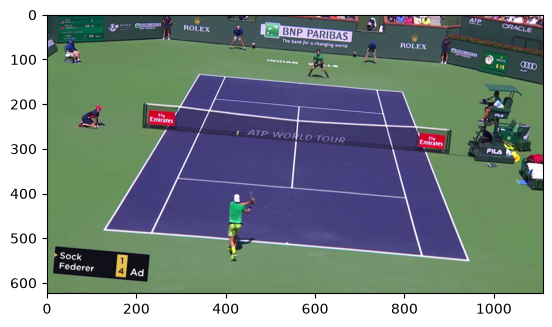

In [ ]:
cropped,baseline_1,baseline_2 = vision_model.crop_based_angle(img)
plt.imshow(cropped)

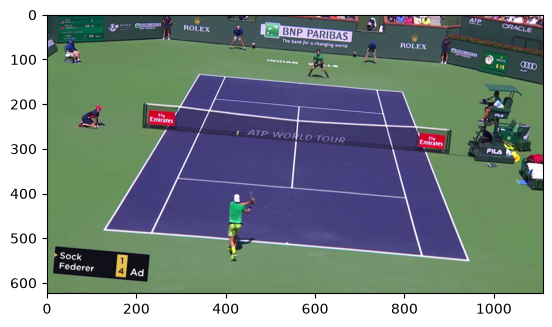

In [53]:
plt.imshow(vision_model.crop_post_process(img,baseline_1,baseline_2))

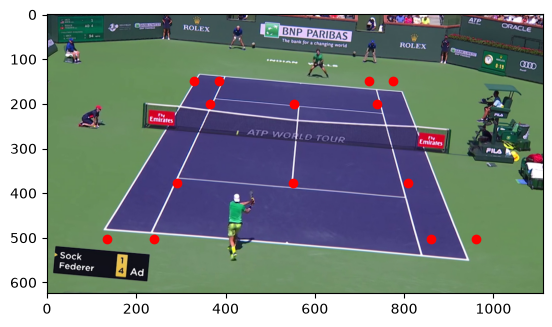

In [48]:
import matplotlib.pyplot as plt
plt.imshow(img)

for point in vision_model.predict(img):
        x, y = point[:2]  # Adjust this if keypoints have more than 2 values
        plt.scatter(x, y, c='r', marker='o')  # Rescale to image size
plt.show()